In [16]:
import pandas as pd

StatementMeta(, bf7a3e4a-a661-472c-9e72-203310c579e9, 30, Finished, Available, Finished)

In [17]:
geolocation = pd.read_csv("/lakehouse/default/Files/olist_geolocation_dataset.csv", dtype={"geolocation_zip_code_prefix": str})
print(geolocation.head())

StatementMeta(, bf7a3e4a-a661-472c-9e72-203310c579e9, 31, Finished, Available, Finished)

  geolocation_zip_code_prefix  geolocation_lat  geolocation_lng  \
0                       01037       -23.545621       -46.639292   
1                       01046       -23.546081       -46.644820   
2                       01046       -23.546129       -46.642951   
3                       01041       -23.544392       -46.639499   
4                       01035       -23.541578       -46.641607   

  geolocation_city geolocation_state  
0        sao paulo                SP  
1        sao paulo                SP  
2        sao paulo                SP  
3        sao paulo                SP  
4        sao paulo                SP  


In [18]:
# Zip latitude and longitude into a tuple of coordinates (latitude, longitude)
geolocation['coordinates'] = list(zip(geolocation['geolocation_lat'], geolocation['geolocation_lng']))

# Delete rows with duplicated coordinates; a coordinate should specify a unique location
geolocs_unique = geolocation.drop_duplicates(subset=['coordinates'], keep='first')

# Drop redundant columns for latitude and longitude
geolocs_unique = geolocs_unique.drop(columns=['geolocation_lat', 'geolocation_lng'])

# Sort by zip code and state
geolocs_unique = geolocs_unique.sort_values(by=['geolocation_zip_code_prefix', 
                                                'geolocation_state', 
                                                'geolocation_city']).reset_index(drop=True)

geolocs_unique.info()
geolocs_unique.head()

StatementMeta(, bf7a3e4a-a661-472c-9e72-203310c579e9, 32, Finished, Available, Finished)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 718463 entries, 0 to 718462
Data columns (total 4 columns):
 #   Column                       Non-Null Count   Dtype 
---  ------                       --------------   ----- 
 0   geolocation_zip_code_prefix  718463 non-null  object
 1   geolocation_city             718463 non-null  object
 2   geolocation_state            718463 non-null  object
 3   coordinates                  718463 non-null  object
dtypes: object(4)
memory usage: 21.9+ MB


,geolocation_zip_code_prefix,geolocation_city,geolocation_state,coordinates
0,01001,sao paulo,SP,"(-23.54929199999999, -46.633559478233785)"
1,01001,sao paulo,SP,"(-23.550497706907517, -46.63433817805407)"
2,01001,sao paulo,SP,"(-23.55064182209015, -46.63440979032252)"
3,01001,sao paulo,SP,"(-23.54969829946912, -46.63390859285005)"
4,01001,sao paulo,SP,"(-23.551426655288804, -46.63407394670785)"


The file 'br-city-codes.csv' contains the most up-to-date list of government-recognized municipalities in Brazil, with their official, correct spellings in Portuguese and zip code ranges. 

Inconsistent spellings may be found in uncleaned datasets due to variations in spacing, hyphenation, capitalization, the use of (non-)accented characters, and other factors. 

If it is absolutely necessary to perform analyses on user-input city names, then one way of handling predictable variations is by performing a fixed set of string transformations on both the user-generated data and official data, so as to allow matching of records based on a 'regularized' string corresponding to a city name; this is identified as 'geolocation_city_ascii' in the DataFrames below. 

However, even after the reconciliation of predictable variants, there is potential for a large residual number of unpredicted variants which would either have to be corrected by hand - a time-consuming task - or if left uncorrected, would lead to inaccuracies in aggregations based on city name. 

Therefore the recommended approach is instead not to rely on user-input city names but perform location-based queries using zip codes, then performing a join on a data dictionary of official municipalities and zip codes in order to retrieve the city names corresponding to location.


In [19]:
# %pip install Unidecode
from unidecode import unidecode
import re

# Load the Brazil cities CSV, preserving only name, state and postal code ranges
br_cities = pd.read_csv('/lakehouse/default/Files/br-city-codes.csv', usecols=['name', 'state', 'postalCode_ranges'])

# Create a new column of city names for string matching purposes 
br_cities['geolocation_city_ascii'] = br_cities['name'].apply(unidecode).str.lower().replace(r'[\W]+', '', regex=True)
br_cities['geolocation_city_ascii'] = br_cities['geolocation_city_ascii'].str.cat(br_cities['state'], sep='_')

print(br_cities.info())


# Use br_cities for city name string matching with geolocations and create another table for zipcode lookup 

def parse_zipcode_ranges(df):
    normalized_rows = []
    for _, row in df.iterrows():
        city = row['name']
        state = row['state']
        ranges_str = row['postalCode_ranges']
        # Extract individual ranges: [00000-000 99999-999]
        range_pattern = r'\[(\d{5})-\d{3}\s+(\d{5})-\d{3}\]'
        matches = re.findall(range_pattern, ranges_str)
        for start_zip, end_zip in matches:
            normalized_rows.append({
                'city': city,
                'state': state,
                'zip_start': start_zip,
                'zip_end': end_zip})
    return pd.DataFrame(normalized_rows)

city_lookup_by_zipcode = parse_zipcode_ranges(br_cities)

print(city_lookup_by_zipcode.info())


# Create a new column of city names for string matching purposes 
geolocs_unique['geolocation_city_ascii'] = geolocs_unique['geolocation_city'].apply(unidecode).str.lower().replace(r'[\W]+', '', regex=True)
geolocs_unique['geolocation_city_ascii'] = geolocs_unique['geolocation_city_ascii'].str.cat(geolocs_unique['geolocation_state'], sep='_')

# Check that 'geolocation_city_ascii' is unique, i.e. no duplicates
print(br_cities[br_cities.duplicated(subset=['geolocation_city_ascii'], keep=False)])

print(geolocs_unique.info())


StatementMeta(, bf7a3e4a-a661-472c-9e72-203310c579e9, 33, Finished, Available, Finished)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5570 entries, 0 to 5569
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   name                    5570 non-null   object
 1   state                   5570 non-null   object
 2   postalCode_ranges       5570 non-null   object
 3   geolocation_city_ascii  5570 non-null   object
dtypes: object(4)
memory usage: 174.2+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5573 entries, 0 to 5572
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   city       5573 non-null   object
 1   state      5573 non-null   object
 2   zip_start  5573 non-null   object
 3   zip_end    5573 non-null   object
dtypes: object(4)
memory usage: 174.3+ KB
None
Empty DataFrame
Columns: [name, state, postalCode_ranges, geolocation_city_ascii]
Index: []
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 718463

In [20]:
"""
This code block runs a validation function for the 'city_lookup_by_zipcode' table to identify gaps in the zipcode ranges.
The missing ranges are added to the table; the null values in these rows for 'city' are replaced by the f"{zip_start}-{zip_end} 
values. This is so that if a zipcode queried in another table happens to be in a missing range, the data point can still 
be sorted/aggregated by a unique value, which can serve as a placeholder until the valid city name corresponding to that 
zipcode is identified. Null values for a state are imputed based on an algorithm that fills in a missing state if the 
zipcode range for that null value is sandwiched by the same state in both the preceding and following zipcode ranges.
"""

def validate_zipcode_coverage(df):
    
    df['start_int'] = df['zip_start'].astype(int)
    df['end_int'] = df['zip_end'].astype(int)
    df_sorted = df.sort_values('start_int')
    
    gaps = []
    
    # Check gap before first range
    first_start = df_sorted['start_int'].iloc[0]
    if first_start > 0:
        gaps.append({
            'gap_start': '00000',
            'gap_end': f"{first_start - 1:05d}",
            'description': 'Gap before first range'})
    
    # Check gaps between ranges
    for i in range(len(df_sorted) - 1):
        current_end = df_sorted['end_int'].iloc[i]
        next_start = df_sorted['start_int'].iloc[i + 1]
        
        if current_end + 1 < next_start:
            gaps.append({
                'gap_start': f"{current_end + 1:05d}",
                'gap_end': f"{next_start - 1:05d}",
                'description': f'Gap between ranges'})
    
    # Check gap after last range
    last_end = df_sorted['end_int'].iloc[-1]
    if last_end < 99999:
        gaps.append({
            'gap_start': f"{last_end + 1:05d}",
            'gap_end': '99999',
            'description': 'Gap after last range'})
    
    return pd.DataFrame(gaps)


def fill_gaps(df, gaps_df):
    unknown_ranges = []
    for _, gap in gaps_df.iterrows():
        unknown_ranges.append({
            'city': f"{gap['gap_start']}-{gap['gap_end']}",
            'state': None,
            'zip_start': gap['gap_start'],
            'zip_end': gap['gap_end']})
    
    return pd.concat([df, pd.DataFrame(unknown_ranges)], ignore_index=True)


def fill_sandwiched_states(df):
    
    # Sort by zip_start to ensure proper ordering
    df = df.sort_values('zip_start').reset_index(drop=True)
    
    # Iterate through rows to find null states
    for i in range(len(df)):
        # Skip if state is not null
        if pd.notna(df.loc[i, 'state']):
            continue
            
        # Get the state of the previous range (if exists)
        prev_state = None
        if i > 0:
            prev_state = df.loc[i-1, 'state']
            
        # Get the state of the next range (if exists)
        next_state = None
        if i < len(df) - 1:
            next_state = df.loc[i+1, 'state']
            
        # If both prev and next exist and are the same (and not null), update
        if (prev_state is not None and 
            next_state is not None and 
            pd.notna(prev_state) and 
            pd.notna(next_state) and 
            prev_state == next_state):
            
            df.loc[i, 'state'] = prev_state
            print(f"Updated row {i}: zip range {df.loc[i, 'zip_start']}-{df.loc[i, 'zip_end']} set to state {prev_state}")
    
    return df


gaps = validate_zipcode_coverage(city_lookup_by_zipcode)
print("Missing ranges:")
print(gaps)

# Fill gaps
city_lookup_by_zipcode = fill_gaps(city_lookup_by_zipcode, gaps)
city_lookup_by_zipcode = city_lookup_by_zipcode.drop(['start_int', 'end_int'], axis=1)
city_lookup_by_zipcode = city_lookup_by_zipcode.sort_values(by=['zip_start', 'zip_end', 'state', 'city'])

# Impute null states
city_lookup_by_zipcode = fill_sandwiched_states(city_lookup_by_zipcode)


print(city_lookup_by_zipcode.info())
print(city_lookup_by_zipcode.head())

StatementMeta(, bf7a3e4a-a661-472c-9e72-203310c579e9, 34, Finished, Available, Finished)

Missing ranges:
   gap_start gap_end             description
0      00000   00999  Gap before first range
1      10000   10999      Gap between ranges
2      28700   28734      Gap between ranges
3      32500   32599      Gap between ranges
4      32700   32899      Gap between ranges
5      34020   34299      Gap between ranges
6      36836   36839      Gap between ranges
7      37549   37549      Gap between ranges
8      38820   38839      Gap between ranges
9      39220   39229      Gap between ranges
10     39998   39999      Gap between ranges
11     45641   45644      Gap between ranges
12     46000   46099      Gap between ranges
13     47860   47899      Gap between ranges
14     54600   54699      Gap between ranges
15     58110   58114      Gap between ranges
16     58310   58314      Gap between ranges
17     58374   58374      Gap between ranges
18     58997   58999      Gap between ranges
19     59187   59187      Gap between ranges
20     64126   64129      Gap between r

### Cleaning the original 'geolocations' table from Kaggle.

The rest of this notebook performs the remaining steps required to clean the original 'geolocations' table from Kaggle. (A de-duplicated and sorted version of this table is created in cell 2 above as _**'geolocs_unique'**_.)

We attempt to reconcile user-input city names with official city names to the maximum extent practicable, by using reasonable string-matching tools and minimizing manual replacement, recognizing that there will be a residue of uncleaned rows that cannot be wrangled without relying on more domain-specific knowledge of the geography of Brazil and relevant factors such as popular naming conventions and alternatives, etc.

In [21]:
#%pip install thefuzz
from thefuzz import process

geolocs_cities = pd.DataFrame(geolocs_unique['geolocation_city_ascii'].unique(), columns=['geolocation_city_ascii'])

print(f"There are {len(geolocs_cities)} unique values of 'geolocation_city_ascii'.")


invalid_cities = geolocs_cities[~geolocs_cities['geolocation_city_ascii'].isin(br_cities['geolocation_city_ascii'])]

print(f"There are {len(invalid_cities)} invalid values of 'geolocation_city_ascii' that need to be cleaned.")

invalid_cities['matches'] = None 
invalid_cities['m1_str'] = None
invalid_cities['wratio'] = None

# This loop checks the string similarity between the invalid and valid 'geolocation_city_ascii'
# strings based on Levenshtein distance, retaining the top 3 matches by WRatio score.
for n in invalid_cities['geolocation_city_ascii']:
    matches = process.extract(n, br_cities['geolocation_city_ascii'], limit=3)
    m1, m2, m3 = matches
    m1_str, wratio, br_cities_index = m1
    invalid_cities.loc[invalid_cities['geolocation_city_ascii'] == n, 'matches'] = str(matches)
    invalid_cities.loc[invalid_cities['geolocation_city_ascii'] == n, 'm1_str'] = str(m1_str)
    invalid_cities.loc[invalid_cities['geolocation_city_ascii'] == n, 'wratio'] = int(wratio)

invalid_cities = invalid_cities.sort_values(by=['wratio', 'geolocation_city_ascii'], ascending=False)
# Sorting the table in descending order of the WRatio score of the top match ('m1_str') allows us to 
# manually inspect the matches to determine the appropriate cutoff point above which the matches are 
# close enough and suited for automatic replacement, and below which the matches are implausible and 
# cannot be reconciled.

print(invalid_cities)

StatementMeta(, bf7a3e4a-a661-472c-9e72-203310c579e9, 35, Finished, Available, Finished)

/tmp/ipykernel_18684/4028073823.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  invalid_cities['matches'] = None
/tmp/ipykernel_18684/4028073823.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  invalid_cities['m1_str'] = None
/tmp/ipykernel_18684/4028073823.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_g

       geolocation_city_ascii  \
2698  jaboataodosgurarapes_PE   
4073    eldoradodoscarajas_PA   
839     camposdosgoytacaze_RJ   
4586   altaflorestadooeste_RO   
3989        senadorlaroque_MA   
...                       ...   
4279             ceilandia_DF   
4277          riachofundo2_DF   
4270             lagonorte_DF   
4276           riachofundo_DF   
4272               lagosul_DF   

                                                matches  \
2698  [('jaboataodosguararapes_PE', 98, 2462), ('abr...   
4073  [('eldoradodocarajas_PA', 98, 1647), ('abaetet...   
839   [('camposdosgoytacazes_RJ', 98, 992), ('aperib...   
4586  [('altaflorestadoeste_RO', 98, 131), ('altopar...   
3989  [('senadorlarocque_MA', 97, 4973), ('anapurus_...   
...                                                 ...   
4279  [('acailandia_MA', 72, 16), ('acrelandia_AC', ...   
4277  [('riachao_MA', 68, 4138), ('riachao_PB', 68, ...   
4270  [('ipirangadonorte_MT', 68, 2237), ('pontealta...   
4276  [('riac

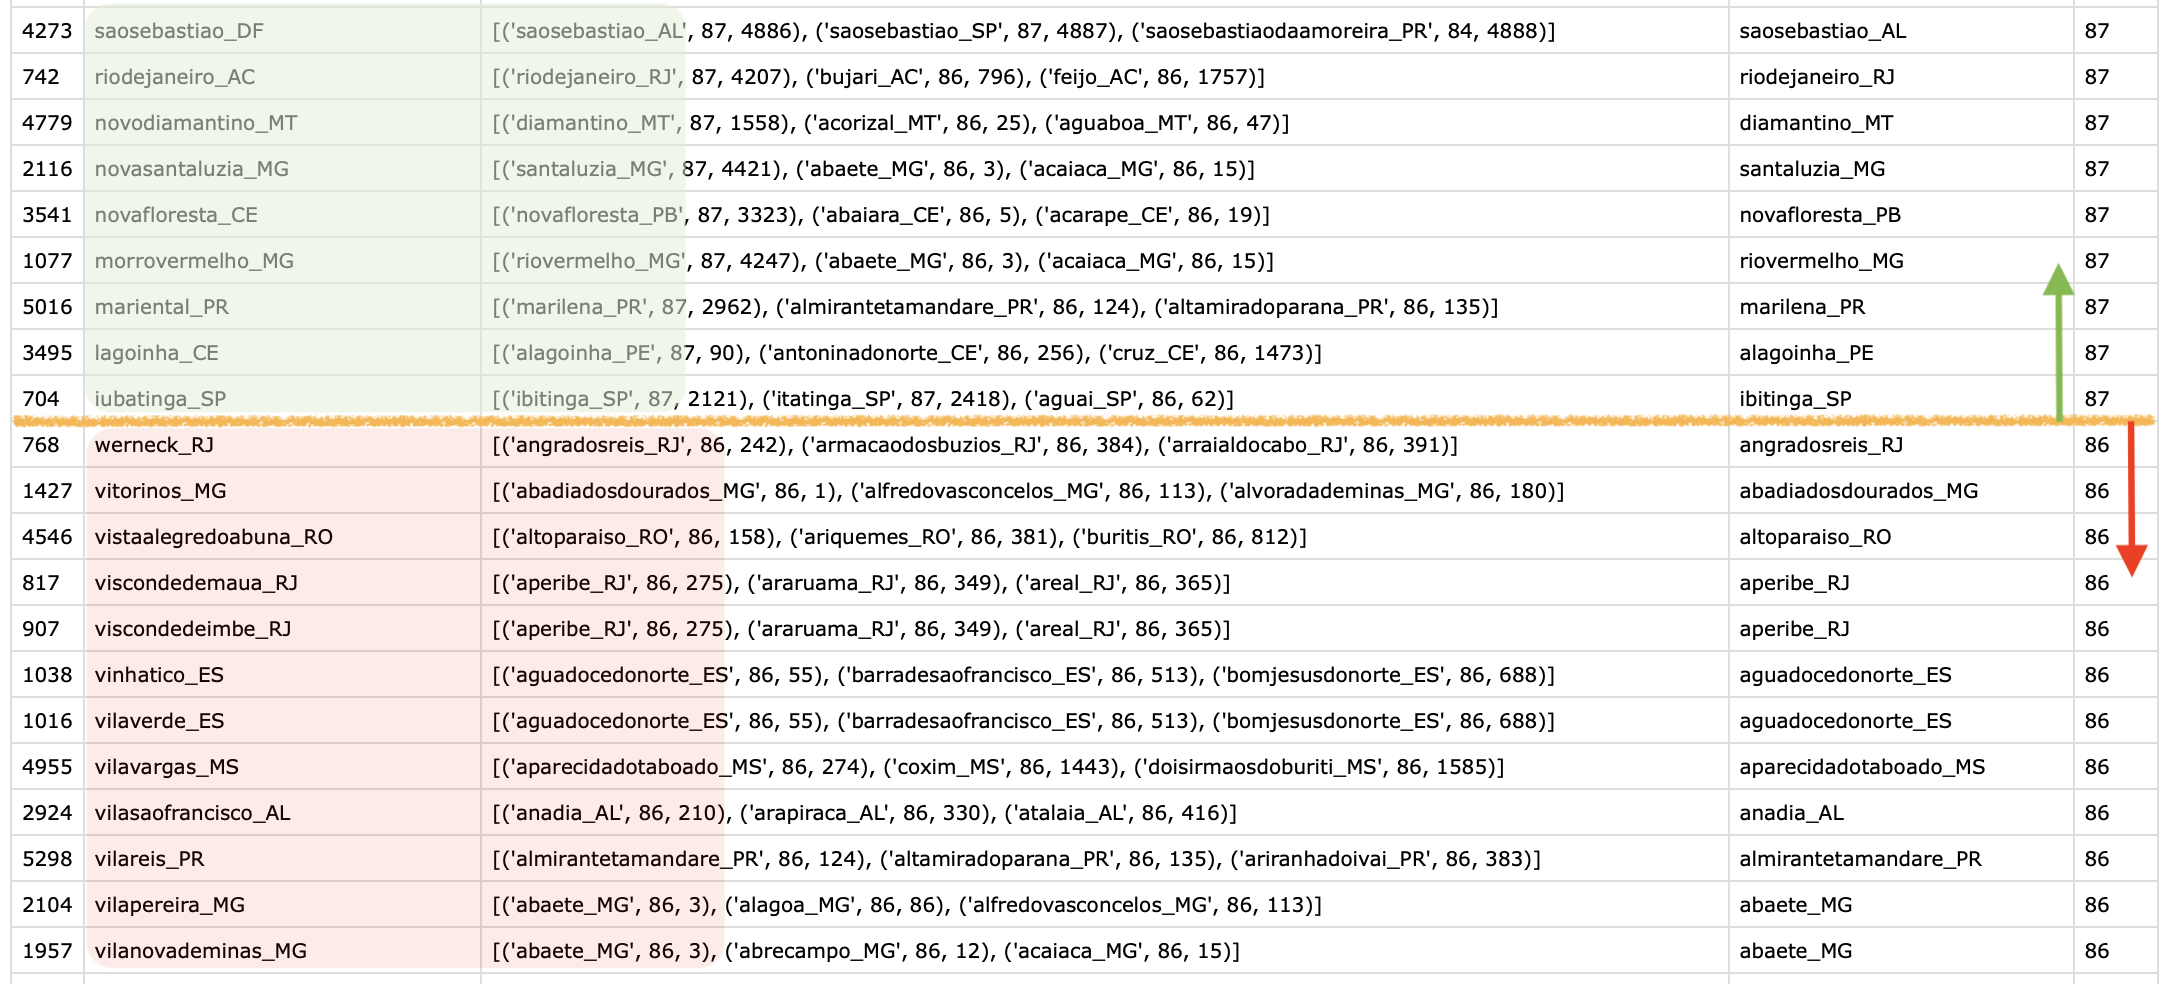

Manual inspection reveals that WRatio scores of <mark>87 and above</mark> mostly do correspond to plausibly similar strings (e.g. typos), whereas scores of 86 and below are mostly not plausible matches.

#### The following classes can be isolated for cleaning:

**Type 1**: Those that match on state suffix and whose city names differ slightly, with WRatio scores >= 87, can be automatically cleaned by substituting with the official name in br_cities.

**Type 2**: Those that have exact matches on city name but differ in state suffix, irrespective of WRatio score, might be
reconcilable by other means, such as checking the zipcode of the record against br_cities to infer if the mismatch might be due to, e.g. typos in the zipcode.

**Type 3**: Those that have a high WRatio score but are clearly not good matches, e.g. 'sp_SP' has a WRatio score of 95 with 'avai_SP', 'bora_SP', 'buri_SP'. It is likely that these have a high score only because very short strings are more easily matched to other strings. As these constitute a very small percentage, they can be dealt with by hand.

#### Procedure:

First, subset all Type 2 records, cross-checking their states and zipcodes with br_cities.

Of the remaining records, drop all rows with WRatio <= 86. Manually remove Type 3 records. 

The remaining records contain the "cleanable" geolocation_city_ascii labels and their matches. This subset is used to do the actual cleaning of the geolocs_unique table itself. 


In [22]:
# Boolean mask to identify records where the invalid user input and its matched string have identical
# city names (but potentially different states).
def same_city_diff_state(row):
    city1, state1 = row['geolocation_city_ascii'].split('_', 1) # split into city and state
    city2, state2 = row['m1_str'].split('_', 1)
    return (city1 == city2) # True if cities match

mask = invalid_cities.apply(same_city_diff_state, axis=1)

invalid_same = invalid_cities[mask] # rows where cities match

print(invalid_same.info())

invalid_diff = invalid_cities[~mask] # rows where cities do not match

print(invalid_diff.info())

# Drop rows with WRatio scores <= 86
invalid_diff = invalid_diff[invalid_diff['wratio'] >= 87]

print(invalid_diff.info())

StatementMeta(, bf7a3e4a-a661-472c-9e72-203310c579e9, 36, Finished, Available, Finished)

<class 'pandas.core.frame.DataFrame'>
Index: 57 entries, 4942 to 4269
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   geolocation_city_ascii  57 non-null     object
 1   matches                 57 non-null     object
 2   m1_str                  57 non-null     object
 3   wratio                  57 non-null     object
dtypes: object(4)
memory usage: 2.2+ KB
None
<class 'pandas.core.frame.DataFrame'>
Index: 751 entries, 2698 to 4272
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   geolocation_city_ascii  751 non-null    object
 1   matches                 751 non-null    object
 2   m1_str                  751 non-null    object
 3   wratio                  751 non-null    object
dtypes: object(4)
memory usage: 29.3+ KB
None
<class 'pandas.core.frame.DataFrame'>
Index: 160 entries, 2698 to 704
Data colum

In [23]:
g2 = invalid_same[['geolocation_city_ascii', 'm1_str']]
g3 = g2.merge(br_cities, how='inner', left_on='m1_str', right_on='geolocation_city_ascii')
g3 = g3.drop(columns=['geolocation_city_ascii_y'])

g4 = g3.merge(geolocs_unique, how='left', left_on='geolocation_city_ascii_x', right_on='geolocation_city_ascii')
g4 = g4.drop(columns=['coordinates', 'geolocation_city_ascii'])
print(g4.info())
print(g4.head())


def unzipcode(string):        
    range_pattern = r'\[(\d{5})-\d{3}\s+(\d{5})-\d{3}\]'
    replacement = r'\1-\2'
    return re.sub(range_pattern, replacement, string)


g4['postalCode_ranges'] = g4['postalCode_ranges'].apply(unzipcode)

splitzip = g4['postalCode_ranges'].str.split('-', expand=True)

g4['zip_start'] = splitzip[0]
g4['zip_end'] = splitzip[1]
g4 = g4.drop(columns=['postalCode_ranges'])

mask = (g4['geolocation_zip_code_prefix'] >= g4['zip_start']) & (g4['geolocation_zip_code_prefix'] <= g4['zip_end']) 

g5 = g4[mask]

print(g5)


StatementMeta(, bf7a3e4a-a661-472c-9e72-203310c579e9, 37, Finished, Available, Finished)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 331 entries, 0 to 330
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   geolocation_city_ascii_x     331 non-null    object
 1   m1_str                       331 non-null    object
 2   name                         331 non-null    object
 3   state                        331 non-null    object
 4   postalCode_ranges            331 non-null    object
 5   geolocation_zip_code_prefix  331 non-null    object
 6   geolocation_city             331 non-null    object
 7   geolocation_state            331 non-null    object
dtypes: object(8)
memory usage: 20.8+ KB
None
  geolocation_city_ascii_x            m1_str             name state  \
0         novaandradina_RS  novaandradina_MS   Nova Andradina    MS   
1         corregodoouro_MG  corregodoouro_GO  Córrego do Ouro    GO   
2         corregodoouro_MG  corregodoouro_GO  Córrego do Ouro    GO

From g5, it can be seen that 3 records from geolocs_unique (corresponding to 2 unique values of geolocation_city_ascii in the 808 records of invalid_cities) can be reconciled based on state. The remaining 55 Type 2 mismatches do not have a zipcode corresponding to the expected range for the city name in the the br_cities reference table. In other words, these are city names not reflected in the official list of municipalities for that state. Without more domain knowledge of why this type of situation arises (e.g. perhaps due to the use of unofficial names by popular convention), there is no principled way of wrangling this class of data further.

In [24]:
# The results of g5 can be used to clean geolocs_unique.

ascii_mapping = dict(zip(g5['geolocation_city_ascii_x'], g5['m1_str']))
city_mapping = dict(zip(g5['geolocation_city_ascii_x'], g5['name']))
state_mapping = dict(zip(g5['geolocation_city_ascii_x'], g5['state']))

geolocs_unique['geolocation_city_ascii'] = geolocs_unique['geolocation_city_ascii'].map(ascii_mapping).fillna(geolocs_unique['geolocation_city_ascii'])
geolocs_unique['geolocation_city'] = geolocs_unique['geolocation_city_ascii'].map(city_mapping).fillna(geolocs_unique['geolocation_city'])
geolocs_unique['geolocation_state'] = geolocs_unique['geolocation_city_ascii'].map(state_mapping).fillna(geolocs_unique['geolocation_state'])


"""
There were originally 6274 unique values of 'geolocation_city_ascii' in geolocs_unique and 808 unique invalid cities.
The code below verifies that geolocs_unique contains 2 fewer instances of 'geolocation_city_ascii' that are invalid, so 
reconciling the Type 2 mismatches as shown in g5 is successful.
"""
geolocs_cities2 = pd.DataFrame(geolocs_unique['geolocation_city_ascii'].unique(), columns=['geolocation_city_ascii'])
print(geolocs_cities2.info())
invalid_cities2 = geolocs_cities2[~geolocs_cities2['geolocation_city_ascii'].isin(br_cities['geolocation_city_ascii'])]
print(invalid_cities2.info())

StatementMeta(, bf7a3e4a-a661-472c-9e72-203310c579e9, 38, Finished, Available, Finished)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6272 entries, 0 to 6271
Data columns (total 1 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   geolocation_city_ascii  6272 non-null   object
dtypes: object(1)
memory usage: 49.1+ KB
None
<class 'pandas.core.frame.DataFrame'>
Index: 806 entries, 1 to 6138
Data columns (total 1 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   geolocation_city_ascii  806 non-null    object
dtypes: object(1)
memory usage: 12.6+ KB
None


In [25]:
# Type 3 mismatches to manually drop
type_3_mismatches = ['sp_SP', 'rj_RJ', 'alexandra_PR']

invalid_diff = invalid_diff[~invalid_diff['geolocation_city_ascii'].isin(type_3_mismatches)]

print(invalid_diff.info())
# Verify that there are now 3 fewer rows of invalid_diff than before.

# To be conservative and not 'over-clean', drop records which have similar city names but different states,
# for the same reasons as the Type 2 residuals.

# Boolean mask to identify records with similar city names but different states.
def find_diff_state(row):
    city1, state1 = row['geolocation_city_ascii'].split('_', 1) # split into city and state
    city2, state2 = row['m1_str'].split('_', 1)
    return (state1 != state2) # True if states do not match

mask = invalid_diff.apply(find_diff_state, axis=1)

invalid_diff = invalid_diff[~mask] # retain rows where condition is False

print(invalid_diff.info())


StatementMeta(, bf7a3e4a-a661-472c-9e72-203310c579e9, 39, Finished, Available, Finished)

<class 'pandas.core.frame.DataFrame'>
Index: 157 entries, 2698 to 704
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   geolocation_city_ascii  157 non-null    object
 1   matches                 157 non-null    object
 2   m1_str                  157 non-null    object
 3   wratio                  157 non-null    object
dtypes: object(4)
memory usage: 6.1+ KB
None
<class 'pandas.core.frame.DataFrame'>
Index: 152 entries, 2698 to 704
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   geolocation_city_ascii  152 non-null    object
 1   matches                 152 non-null    object
 2   m1_str                  152 non-null    object
 3   wratio                  152 non-null    object
dtypes: object(4)
memory usage: 5.9+ KB
None


In [26]:
# invalid_diff can be used to clean geolocs_unique

# Define mappings from the uncleaned to cleaned geolocation_city_ascii strings
ascii_mapping2 = dict(zip(invalid_diff['geolocation_city_ascii'], invalid_diff['m1_str']))
# Define mappings from the cleaned geolocation_city_ascii strings to the offical city names
city_mapping2 = dict(zip(br_cities['geolocation_city_ascii'], br_cities['name']))

# Apply the mappings defined above.
geolocs_unique['geolocation_city_ascii'] = geolocs_unique['geolocation_city_ascii'].map(ascii_mapping2).fillna(geolocs_unique['geolocation_city_ascii'])
geolocs_unique['geolocation_city'] = geolocs_unique['geolocation_city_ascii'].map(city_mapping2).fillna(geolocs_unique['geolocation_city'])


"""
There were 806 unique values of 'geolocation_city_ascii' in invalid_cities2.
The code below verifies that invalid_cities3 contains 152 fewer instances of 'geolocation_city_ascii' that are invalid, so 
reconciling the Type 1 mismatches in geolocs_unique is successful.
"""

geolocs_cities3 = pd.DataFrame(geolocs_unique['geolocation_city_ascii'].unique(), columns=['geolocation_city_ascii'])

invalid_cities3 = geolocs_cities3[~geolocs_cities3['geolocation_city_ascii'].isin(br_cities['geolocation_city_ascii'])]

print(invalid_cities3.info())

# Boolean mask to subset unvalidated city names in geolocs_unique
residual_invalid_cities = ~geolocs_unique['geolocation_city_ascii'].isin(br_cities['geolocation_city_ascii'])

# Create a new column city_name_validated to record whether the city name has been validated.
geolocs_unique['city_name_validated'] = None
geolocs_unique.loc[residual_invalid_cities, 'city_name_validated'] = False
geolocs_unique = geolocs_unique.fillna(value=True)

print(geolocs_unique.info())
print(geolocs_unique)


StatementMeta(, bf7a3e4a-a661-472c-9e72-203310c579e9, 40, Finished, Available, Finished)

<class 'pandas.core.frame.DataFrame'>
Index: 654 entries, 1 to 5996
Data columns (total 1 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   geolocation_city_ascii  654 non-null    object
dtypes: object(1)
memory usage: 10.2+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 718463 entries, 0 to 718462
Data columns (total 6 columns):
 #   Column                       Non-Null Count   Dtype 
---  ------                       --------------   ----- 
 0   geolocation_zip_code_prefix  718463 non-null  object
 1   geolocation_city             718463 non-null  object
 2   geolocation_state            718463 non-null  object
 3   coordinates                  718463 non-null  object
 4   geolocation_city_ascii       718463 non-null  object
 5   city_name_validated          718463 non-null  bool  
dtypes: bool(1), object(5)
memory usage: 28.1+ MB
None
       geolocation_zip_code_prefix geolocation_city geolocation_state

In [27]:
"""
# Write the table to the silver lakehouse as a delta table
# Convert pandas to Spark
spark_city_lookup_by_zipcode = spark.createDataFrame(city_lookup_by_zipcode)

# Save as a Delta table in Silver Lakehouse
silver_path = "SilverLakehouse.dbo.city_lookup_by_zipcode"
spark_city_lookup_by_zipcode.write.format("delta").mode("overwrite").saveAsTable(silver_path)
"""

StatementMeta(, bf7a3e4a-a661-472c-9e72-203310c579e9, 41, Finished, Available, Finished)

'\n# Write the table to the silver lakehouse as a delta table\n# Convert pandas to Spark\nspark_city_lookup_by_zipcode = spark.createDataFrame(city_lookup_by_zipcode)\n\n# Save as a Delta table in Silver Lakehouse\nsilver_path = "SilverLakehouse.dbo.city_lookup_by_zipcode"\nspark_city_lookup_by_zipcode.write.format("delta").mode("overwrite").saveAsTable(silver_path)\n'

In [29]:
# Write the table to the silver lakehouse as a delta table
# Convert pandas to Spark
spark_geolocs_unique = spark.createDataFrame(geolocs_unique)

# Save as a Delta table in Silver Lakehouse
silver_path = "SilverLakehouse.dbo.olist_geolocation_cleaned"
spark_geolocs_unique.write.format("delta").mode("overwrite").saveAsTable(silver_path)

StatementMeta(, bf7a3e4a-a661-472c-9e72-203310c579e9, 43, Finished, Available, Finished)